# Lab: Efficient Storage and Serialisation in Python

This lab uses the **NYC TLC Yellow Taxi** trip records as a realistic tabular dataset.

The focus is: "Which format is best for my data?"

Main goals:

- compare text and binary storage
- compare row style and column style thinking
- use `CSV`, `Pickle`, `Parquet`, `Feather`, and NumPy `NPZ`
- inspect Arrow schemas
- measure file size, write time, and read time
- decide which format fits which task

## 1) Setup

For this lab, you may need:

```bash
pip install pandas numpy
```

In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd

### 1.1) Download and load the dataset

This notebook uses one official monthly Yellow Taxi parquet file from the [NYC TLC data portal](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page).

We use one monthly parquet file, then keep only a manageable sample for the lab.

You can change the URL to another month later.

In [2]:
DATA_DIR = Path("storage_lab_data")
DATA_DIR.mkdir(exist_ok=True)

url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2022-01.parquet"
parquet_source = DATA_DIR / "yellow_tripdata_2022_01.parquet"

if not parquet_source.exists():
    df_full = pd.read_parquet(url)
    df_full.to_parquet(parquet_source, index=False)
else:
    df_full = pd.read_parquet(parquet_source)

print(f"Full shape: {df_full.shape}")
df_full.head()

Full shape: (2463931, 19)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2022-01-01 00:35:40,2022-01-01 00:53:29,2.0,3.80,1.0,N,142,236,1,14.5,3.0,0.5,3.65,0.0,0.3,21.95,2.5,0.0
1,1,2022-01-01 00:33:43,2022-01-01 00:42:07,1.0,2.10,1.0,N,236,42,1,8.0,0.5,0.5,4.00,0.0,0.3,13.30,0.0,0.0
2,2,2022-01-01 00:53:21,2022-01-01 01:02:19,1.0,0.97,1.0,N,166,166,1,7.5,0.5,0.5,1.76,0.0,0.3,10.56,0.0,0.0
3,2,2022-01-01 00:25:21,2022-01-01 00:35:23,1.0,1.09,1.0,N,114,68,2,8.0,0.5,0.5,0.00,0.0,0.3,11.80,2.5,0.0
4,2,2022-01-01 00:36:48,2022-01-01 01:14:20,1.0,4.30,1.0,N,68,163,1,23.5,0.5,0.5,3.00,0.0,0.3,30.30,2.5,0.0


**Notice that the original file to download is in `parquet` format.**

💭 Why do you think this is the case? 🤔

👉 The answer is provided in the [Take-home](#33-take-home-lessons) part.

### 1.2) Build a neat working subset

We keep only selected columns and a fixed sample size.
This keeps the lab fast and reproducible.

In [3]:
columns = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "passenger_count",
    "trip_distance",
    "RatecodeID",
    "store_and_fwd_flag",
    "PULocationID",
    "DOLocationID",
    "payment_type",
    "fare_amount",
    "extra",
    "mta_tax",
    "tip_amount",
    "tolls_amount",
    "total_amount",
]

df = df_full[columns].sample(n=100_000, random_state=42).reset_index(drop=True).copy()

# Light cleanup for consistency
df["store_and_fwd_flag"] = df["store_and_fwd_flag"].astype("category")
df["payment_type"] = df["payment_type"].astype("Int64")
df["RatecodeID"] = df["RatecodeID"].astype("Int64")
df["PULocationID"] = df["PULocationID"].astype("Int64")
df["DOLocationID"] = df["DOLocationID"].astype("Int64")

print(df.shape)
df.head()

(100000, 15)


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,total_amount
0,2022-01-15 00:22:49,2022-01-15 00:31:33,2.0,1.50,1,N,148,209,1,8.0,3.0,0.5,2.36,0.0,14.16
1,2022-01-13 17:50:32,2022-01-13 18:03:09,1.0,2.60,1,N,48,238,1,11.0,3.5,0.5,1.00,0.0,16.30
2,2022-01-19 18:41:39,2022-01-19 18:56:29,1.0,3.73,1,N,141,24,1,13.5,1.0,0.5,3.56,0.0,21.36
3,2022-01-08 10:35:44,2022-01-08 10:45:53,1.0,5.96,1,N,231,140,1,17.5,0.0,0.5,4.16,0.0,24.96
4,2022-01-26 20:08:13,2022-01-26 20:12:15,2.0,0.69,1,N,229,162,2,5.0,0.5,0.5,0.00,0.0,8.80


### 1.3) Quick `dtype` inspection

Storage format choice becomes much easier when you look at data types first.

In [4]:
df.dtypes

tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                        Int64
store_and_fwd_flag             category
PULocationID                      Int64
DOLocationID                      Int64
payment_type                      Int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
total_amount                    float64
dtype: object

## 2) Exercises

### 2.0) Helper functions for benchmarking

We measure:

- Write time
- Read time
- File size

Implement functions that measure execution time and file size.

You are expected to use these functions for every exercise in this section, and compare the results afterwards.

In [5]:
def file_size_mb(path):
    return Path(path).stat().st_size / (1024**2)


def time_call(fn, warmup=3, repeat=10):
    for _ in range(warmup):
        fn()

    times = []
    out = None
    for _ in range(repeat):
        start = time.perf_counter()
        out = fn()
        end = time.perf_counter()
        times.append(end - start)

    # This time_call focuses on the minimum time,
    #   which is more representative of the best-case performance of the function.
    return out, min(times)


RESULTS = []
OUT_DIR = DATA_DIR / "outputs"
OUT_DIR.mkdir(exist_ok=True)

### 2.1) NPY and NPZ

Save the `df` in `.npy` and/or `.npz` format 🤔👀

💭 Useful for numeric arrays.
Not a replacement for dataframe storage.

From the [NumPy official docs](https://numpy.org/doc/stable/reference/generated/numpy.lib.format.html#npy-format):
> The `.npy` format is the standard binary file format in NumPy for persisting a single arbitrary NumPy array on disk. The `.npz` format is the standard format for persisting multiple NumPy arrays on disk. A `.npz` file is a zip file containing multiple `.npy` files, one for each array.

In [9]:
X = df.to_numpy()
print(X.shape)
print(X[:5])

(100000, 15)
[[Timestamp('2022-01-15 00:22:49') Timestamp('2022-01-15 00:31:33') 2.0
  1.5 1 'N' 148 209 1 8.0 3.0 0.5 2.36 0.0 14.16]
 [Timestamp('2022-01-13 17:50:32') Timestamp('2022-01-13 18:03:09') 1.0
  2.6 1 'N' 48 238 1 11.0 3.5 0.5 1.0 0.0 16.3]
 [Timestamp('2022-01-19 18:41:39') Timestamp('2022-01-19 18:56:29') 1.0
  3.73 1 'N' 141 24 1 13.5 1.0 0.5 3.56 0.0 21.36]
 [Timestamp('2022-01-08 10:35:44') Timestamp('2022-01-08 10:45:53') 1.0
  5.96 1 'N' 231 140 1 17.5 0.0 0.5 4.16 0.0 24.96]
 [Timestamp('2022-01-26 20:08:13') Timestamp('2022-01-26 20:12:15') 2.0
  0.69 1 'N' 229 162 2 5.0 0.5 0.5 0.0 0.0 8.8]]


In [11]:
# NPZ
# Notice the use of `allow_pickle=True` when loading, which is necessary for loading object arrays.
npz_path = OUT_DIR / "taxi_arrays.npz"
_, write_s = time_call(lambda: np.savez(npz_path, X=X))
_, read_s = time_call(lambda: np.load(npz_path, allow_pickle=True)["X"])

RESULTS.append(
    {
        "format": "npz",
        "write_s": write_s,
        "read_s": read_s,
        "size_mb": file_size_mb(npz_path),
    }
)

# NPZ compressed
npz_comp_path = OUT_DIR / "taxi_arrays_compressed.npz"
_, write_s = time_call(lambda: np.savez_compressed(npz_comp_path, X=X))
_, read_s = time_call(lambda: np.load(npz_comp_path, allow_pickle=True)["X"])

RESULTS.append(
    {
        "format": "npz_compressed",
        "write_s": write_s,
        "read_s": read_s,
        "size_mb": file_size_mb(npz_comp_path),
    }
)

### 2.2) CSV
Save the `df` as `.csv`.

💭 CSV is a good baseline.
Readable, portable, but often larger and slower to parse.

In [12]:
csv_path = OUT_DIR / "taxi_sample.csv"

_, write_s = time_call(lambda: df.to_csv(csv_path, index=False))
df_csv, read_s = time_call(
    lambda: pd.read_csv(
        csv_path, parse_dates=["tpep_pickup_datetime", "tpep_dropoff_datetime"]
    )
)

RESULTS.append(
    {
        "format": "csv",
        "write_s": write_s,
        "read_s": read_s,
        "size_mb": file_size_mb(csv_path),
    }
)

df_csv.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,total_amount
0,2022-01-15 00:22:49,2022-01-15 00:31:33,2.0,1.50,1.0,N,148,209,1,8.0,3.0,0.5,2.36,0.0,14.16
1,2022-01-13 17:50:32,2022-01-13 18:03:09,1.0,2.60,1.0,N,48,238,1,11.0,3.5,0.5,1.00,0.0,16.30
2,2022-01-19 18:41:39,2022-01-19 18:56:29,1.0,3.73,1.0,N,141,24,1,13.5,1.0,0.5,3.56,0.0,21.36
3,2022-01-08 10:35:44,2022-01-08 10:45:53,1.0,5.96,1.0,N,231,140,1,17.5,0.0,0.5,4.16,0.0,24.96
4,2022-01-26 20:08:13,2022-01-26 20:12:15,2.0,0.69,1.0,N,229,162,2,5.0,0.5,0.5,0.00,0.0,8.80


### 2.3) Pickle

"Pickle" the `df`.

💭 Very convenient inside Python, but Python specific and not safe for untrusted files.

In [13]:
pkl_path = OUT_DIR / "taxi_sample.pkl"

_, write_s = time_call(lambda: df.to_pickle(pkl_path))
df_pkl, read_s = time_call(lambda: pd.read_pickle(pkl_path))

RESULTS.append(
    {
        "format": "pickle",
        "write_s": write_s,
        "read_s": read_s,
        "size_mb": file_size_mb(pkl_path),
    }
)

df_pkl.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,total_amount
0,2022-01-15 00:22:49,2022-01-15 00:31:33,2.0,1.50,1,N,148,209,1,8.0,3.0,0.5,2.36,0.0,14.16
1,2022-01-13 17:50:32,2022-01-13 18:03:09,1.0,2.60,1,N,48,238,1,11.0,3.5,0.5,1.00,0.0,16.30
2,2022-01-19 18:41:39,2022-01-19 18:56:29,1.0,3.73,1,N,141,24,1,13.5,1.0,0.5,3.56,0.0,21.36
3,2022-01-08 10:35:44,2022-01-08 10:45:53,1.0,5.96,1,N,231,140,1,17.5,0.0,0.5,4.16,0.0,24.96
4,2022-01-26 20:08:13,2022-01-26 20:12:15,2.0,0.69,1,N,229,162,2,5.0,0.5,0.5,0.00,0.0,8.80


### 2.4) Parquet
Save the `df` as `.parquet`.

💭 Main modern tabular format in this lab.
Typed, compressed, and efficient for analytics.

In [14]:
pq_path = OUT_DIR / "taxi_sample.parquet"

_, write_s = time_call(lambda: df.to_parquet(pq_path, index=False))
df_pq, read_s = time_call(lambda: pd.read_parquet(pq_path))

RESULTS.append(
    {
        "format": "parquet",
        "write_s": write_s,
        "read_s": read_s,
        "size_mb": file_size_mb(pq_path),
    }
)

df_pq.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,total_amount
0,2022-01-15 00:22:49,2022-01-15 00:31:33,2.0,1.50,1,N,148,209,1,8.0,3.0,0.5,2.36,0.0,14.16
1,2022-01-13 17:50:32,2022-01-13 18:03:09,1.0,2.60,1,N,48,238,1,11.0,3.5,0.5,1.00,0.0,16.30
2,2022-01-19 18:41:39,2022-01-19 18:56:29,1.0,3.73,1,N,141,24,1,13.5,1.0,0.5,3.56,0.0,21.36
3,2022-01-08 10:35:44,2022-01-08 10:45:53,1.0,5.96,1,N,231,140,1,17.5,0.0,0.5,4.16,0.0,24.96
4,2022-01-26 20:08:13,2022-01-26 20:12:15,2.0,0.69,1,N,229,162,2,5.0,0.5,0.5,0.00,0.0,8.80


### 2.5) Feather
Save the `df` as `.feather`.


💭 Feather is Arrow based and convenient for fast local dataframe storage.

In [15]:
feather_path = OUT_DIR / "taxi_sample.feather"

_, write_s = time_call(lambda: df.to_feather(feather_path))
df_feather, read_s = time_call(lambda: pd.read_feather(feather_path))

RESULTS.append(
    {
        "format": "feather",
        "write_s": write_s,
        "read_s": read_s,
        "size_mb": file_size_mb(feather_path),
    }
)

df_feather.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,total_amount
0,2022-01-15 00:22:49,2022-01-15 00:31:33,2.0,1.50,1,N,148,209,1,8.0,3.0,0.5,2.36,0.0,14.16
1,2022-01-13 17:50:32,2022-01-13 18:03:09,1.0,2.60,1,N,48,238,1,11.0,3.5,0.5,1.00,0.0,16.30
2,2022-01-19 18:41:39,2022-01-19 18:56:29,1.0,3.73,1,N,141,24,1,13.5,1.0,0.5,3.56,0.0,21.36
3,2022-01-08 10:35:44,2022-01-08 10:45:53,1.0,5.96,1,N,231,140,1,17.5,0.0,0.5,4.16,0.0,24.96
4,2022-01-26 20:08:13,2022-01-26 20:12:15,2.0,0.69,1,N,229,162,2,5.0,0.5,0.5,0.00,0.0,8.80


### 2.6) Compare results

Compare all the data you gathered above and plot the results.

In [16]:
results_df = pd.DataFrame(RESULTS).sort_values("size_mb").reset_index(drop=True)
results_df

,format,write_s,read_s,size_mb
0,parquet,0.027515,0.003326,2.692210
1,npz_compressed,0.363794,0.236568,2.707330
2,feather,0.007223,0.002703,3.839617
3,csv,0.365042,0.111835,8.460334
4,pickle,0.003949,0.001580,11.160337
5,npz,0.133848,0.251440,11.677542


Below are two comparison plots with different features that present the results from different perspectives.


#### 2.6.1) Comparison plot - I

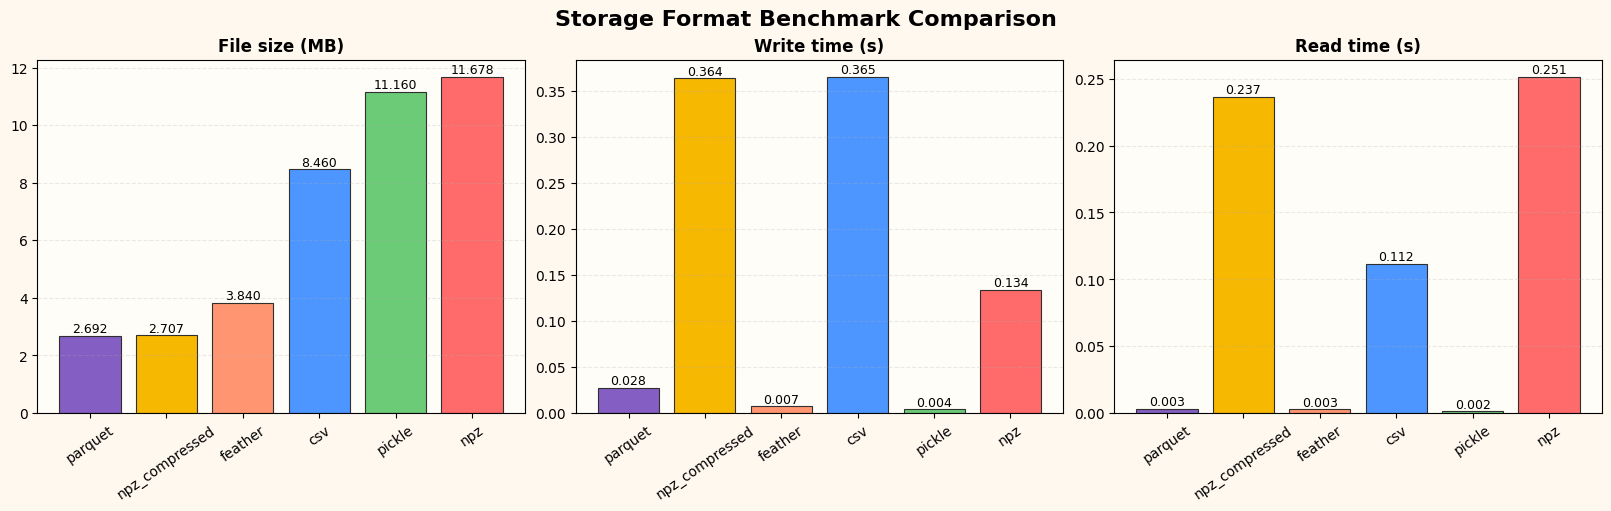

In [17]:
import matplotlib.pyplot as plt

plot_df = results_df.set_index("format")
metrics = ["size_mb", "write_s", "read_s"]
titles = ["File size (MB)", "Write time (s)", "Read time (s)"]
colors = {
    "npz": "#ff6b6b",
    "npz_compressed": "#f7b801",
    "csv": "#4d96ff",
    "pickle": "#6bcB77",
    "parquet": "#845ec2",
    "feather": "#ff9671",
}
bar_colors = [colors.get(fmt, "#8884d8") for fmt in plot_df.index]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
fig.patch.set_facecolor("#fff8ef")

for ax, metric, title in zip(axes, metrics, titles):
    bars = ax.bar(
        plot_df.index,
        plot_df[metric],
        color=bar_colors,
        edgecolor="#2f2f2f",
        linewidth=0.8,
    )
    ax.set_title(title, fontsize=12, weight="bold")
    ax.set_facecolor("#fffdf8")
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.tick_params(axis="x", rotation=35)

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

fig.suptitle("Storage Format Benchmark Comparison", fontsize=16, weight="bold")
plt.show()

#### 2.6.2) Comparison plot - II

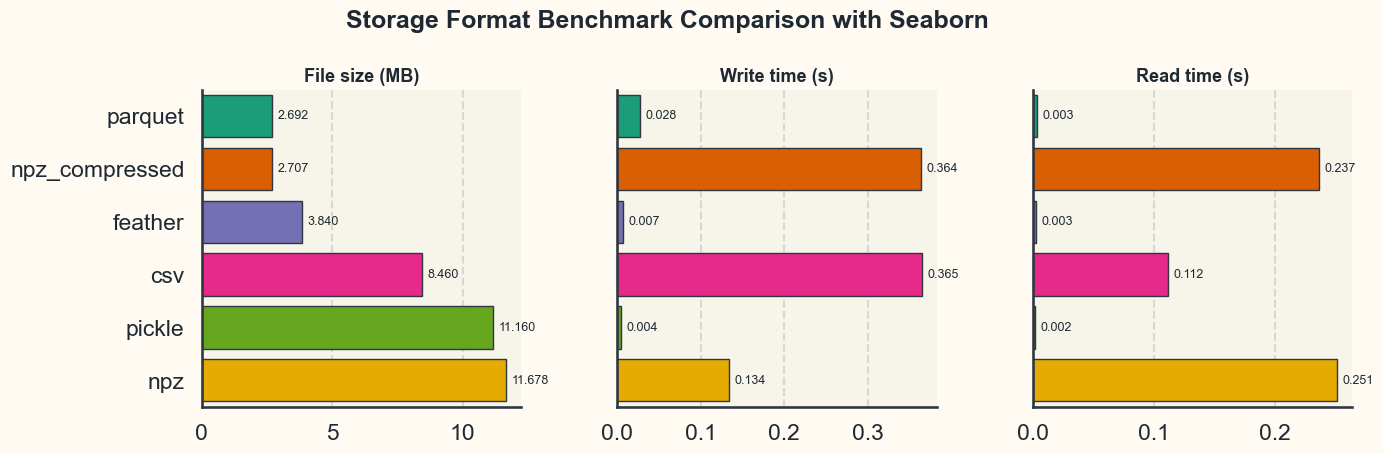

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    context="talk",
    rc={
        "axes.facecolor": "#f7f4ea",
        "figure.facecolor": "#fffaf2",
        "grid.color": "#9aa4b2",
        "grid.alpha": 0.4,
        "axes.edgecolor": "#2f3640",
        "axes.labelcolor": "#1f2933",
        "text.color": "#1f2933",
        "xtick.color": "#1f2933",
        "ytick.color": "#1f2933",
    },
)

plot_long = results_df.melt(
    id_vars="format",
    value_vars=["size_mb", "write_s", "read_s"],
    var_name="metric",
    value_name="value",
)

metric_labels = {
    "size_mb": "File size (MB)",
    "write_s": "Write time (s)",
    "read_s": "Read time (s)",
}
format_order = results_df["format"].tolist()
palette = dict(
    zip(format_order, sns.color_palette("Dark2", n_colors=len(format_order)))
)

g = sns.catplot(
    data=plot_long,
    kind="bar",
    x="value",
    y="format",
    hue="format",
    col="metric",
    order=format_order,
    palette=palette,
    sharex=False,
    height=5,
    aspect=0.95,
    legend=False,
    saturation=1,
    edgecolor="#2f3640",
    linewidth=1,
)

g.set_titles("{col_name}")
g.set_axis_labels("", "")
g.figure.subplots_adjust(top=0.82, wspace=0.3)
g.figure.suptitle(
    "Storage Format Benchmark Comparison with Seaborn",
    fontsize=18,
    weight="bold",
)

for ax in g.axes.flat:
    ax.set_title(metric_labels[ax.get_title()], fontsize=13, weight="bold")
    ax.grid(axis="x", linestyle="--", alpha=0.35)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=4, fontsize=9)

plt.show()

### 2.7) Optional extension

Try one of these:

- compare `np.save` with `np.savez_compressed`
- test another sample size
- test another month of NYC taxi data
- add memory profiling with `df.memory_usage(deep=True)`

## 3) Observation and Discussion

### 3.1) Check dtype preservation

Formats differ in how well they preserve structure and types. Check the data type of the data you saved.

In [24]:
dtype_compare = pd.DataFrame(
    {
        "original": df.dtypes.astype(str),
        "csv": df_csv.dtypes.astype(str),
        "pickle": df_pkl.dtypes.astype(str),
        "parquet": df_pq.dtypes.astype(str),
        "feather": df_feather.dtypes.astype(str),
        "npz": pd.Series(
            {
                column: str(pd.Series(X[:, i]).dtype)
                for i, column in enumerate(df.columns)
            }
        ),
    }
)

dtype_compare

,original,csv,pickle,parquet,feather,npz
tpep_pickup_datetime,datetime64[us],datetime64[us],datetime64[us],datetime64[us],datetime64[us],datetime64[us]
tpep_dropoff_datetime,datetime64[us],datetime64[us],datetime64[us],datetime64[us],datetime64[us],datetime64[us]
passenger_count,float64,float64,float64,float64,float64,object
trip_distance,float64,float64,float64,float64,float64,object
RatecodeID,Int64,float64,Int64,Int64,Int64,object
store_and_fwd_flag,category,str,category,category,category,str
PULocationID,Int64,int64,Int64,Int64,Int64,object
DOLocationID,Int64,int64,Int64,Int64,Int64,object
payment_type,Int64,int64,Int64,Int64,Int64,object
fare_amount,float64,float64,float64,float64,float64,object


The `npz` _object_ column type reflects the limitation of storing the whole mixed DataFrame as one NumPy array.

### 3.2) Parquet column selection demo

`Parquet` is especially well suited to columnar storage and column wise reading. Read a few columns from your saved Parquet data while tracking the read time.

In [23]:
small_cols = ["trip_distance", "fare_amount", "tip_amount"]

_, parquet_small_read_s = time_call(
    lambda: pd.read_parquet(pq_path, columns=small_cols)
)
_, csv_small_read_s = time_call(lambda: pd.read_csv(csv_path, usecols=small_cols))

pd.DataFrame(
    {
        "operation": ["read 3 columns from parquet", "read 3 columns from csv"],
        "time_s": [parquet_small_read_s, csv_small_read_s],
    }
)

,operation,time_s
0,read 3 columns from parquet,0.000985
1,read 3 columns from csv,0.033243


### 3.3) Take-home lessons

- `CSV` is simple and portable, but often larger and slower in I/O.
- `Pickle` is convenient for Python only workflows.
- `Parquet` is usually the best default for analytical tabular data in terms of long-term storage, data archiving, and efficient disk I/O.
- `Feather` is a handy Arrow based option for fast local DataFrame exchange, especially between Python and R.
- `NPZ` is good for numeric arrays, not mixed tabular datasets.
- `Arrow` is an in-memory columnar format enabling efficient data processing.